# MNIST: EDA + CNN Classification

A course-ready notebook covering dataset exploration and a Convolutional Neural Network built with Keras, with line-by-line explanations.

## 1. Load Dataset

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print("Data type:", X_train.dtype)
print("Pixel value range:", X_train.min(), "to", X_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Data type: uint8
Pixel value range: 0 to 255


## 2. Class Distribution (Train vs Test)
Checking whether classes are balanced.

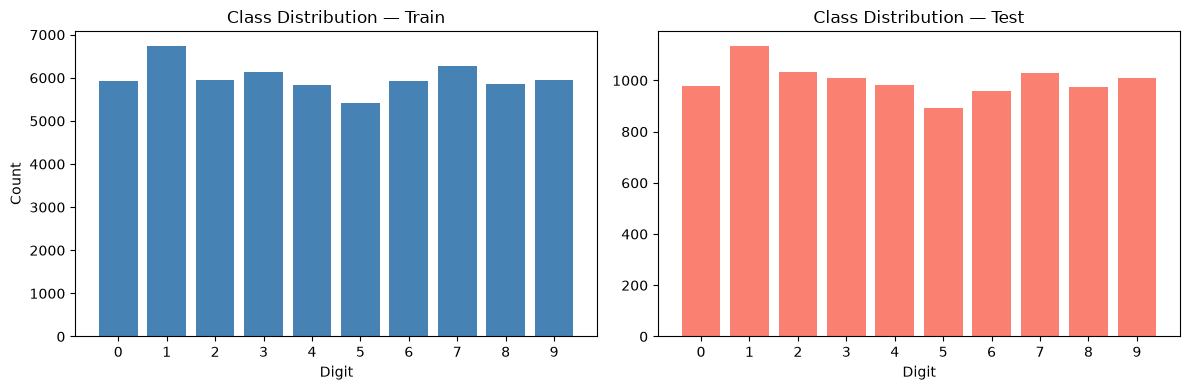

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unique_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(unique_train, counts_train, color="steelblue")
axes[0].set_title("Class Distribution — Train")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(10))

unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(unique_test, counts_test, color="salmon")
axes[1].set_title("Class Distribution — Test")
axes[1].set_xlabel("Digit")
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

## 3. Sample Images Grid

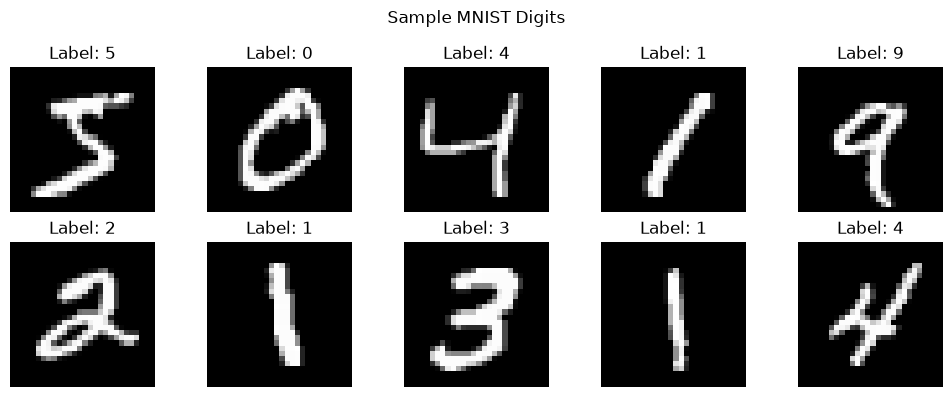

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample MNIST Digits")
plt.tight_layout()
plt.show()

## 4. One Example Per Digit (0-9)

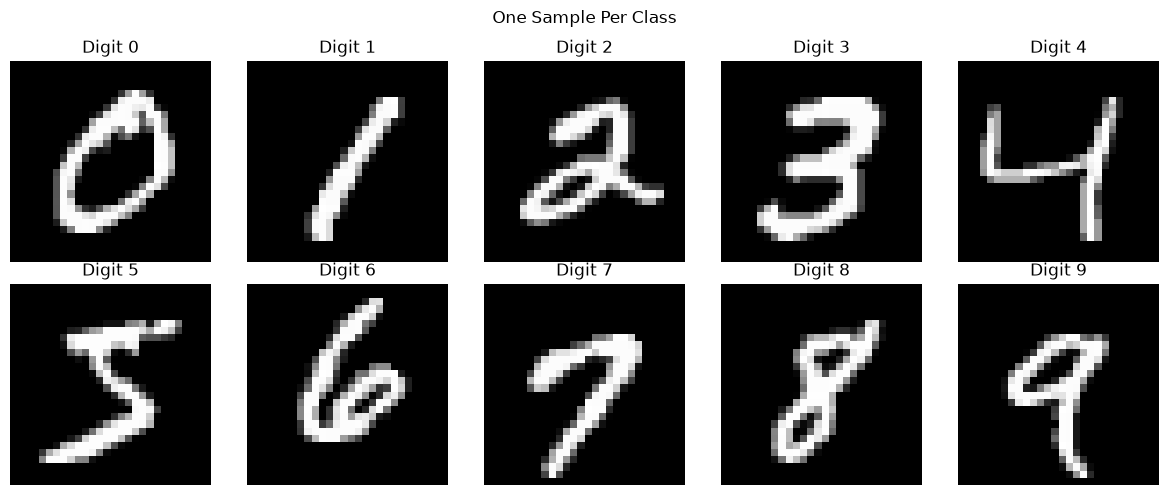

In [4]:
plt.figure(figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(f"Digit {digit}")
    plt.axis("off")
plt.suptitle("One Sample Per Class")
plt.tight_layout()
plt.show()

## 5. Average (\"Mean\") Image Per Digit
Shows the prototype shape the model needs to learn for each class.

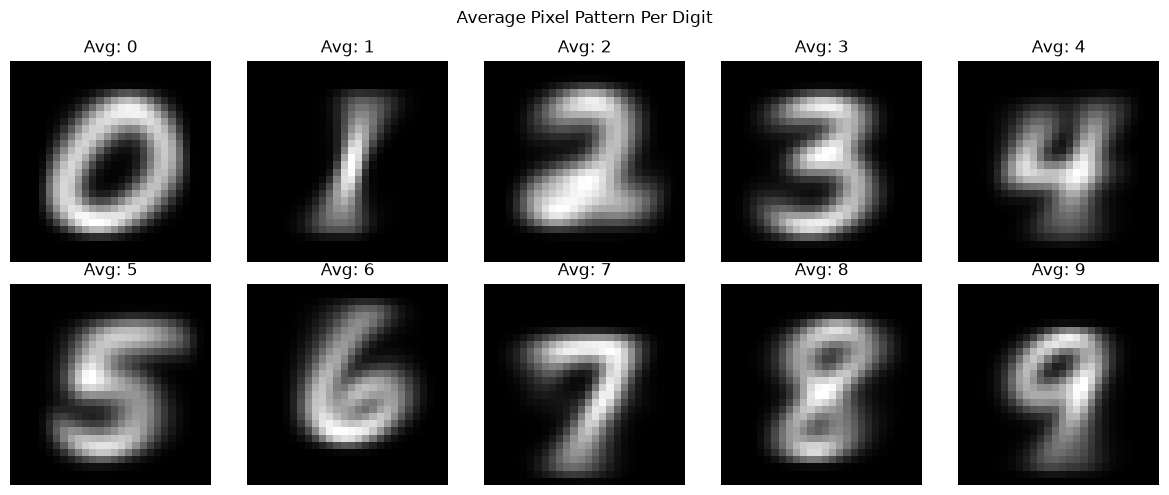

In [5]:
plt.figure(figsize=(12, 5))
for digit in range(10):
    avg_image = X_train[y_train == digit].mean(axis=0)
    plt.subplot(2, 5, digit + 1)
    plt.imshow(avg_image, cmap="gray")
    plt.title(f"Avg: {digit}")
    plt.axis("off")
plt.suptitle("Average Pixel Pattern Per Digit")
plt.tight_layout()
plt.show()

## 6. Pixel Intensity Distribution

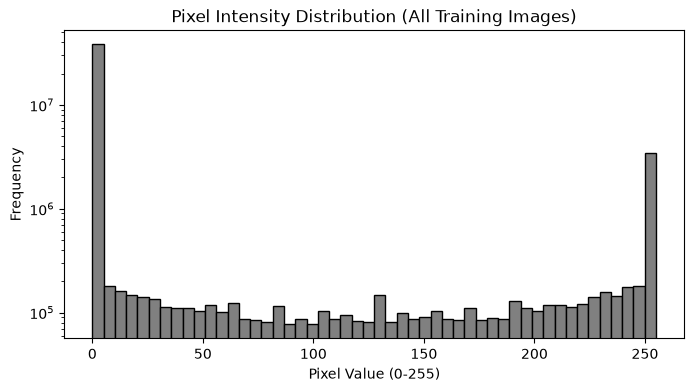

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(X_train.flatten(), bins=50, color="gray", edgecolor="black")
plt.title("Pixel Intensity Distribution (All Training Images)")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

## 7. Duplicate Image Check

In [7]:
flat_train = X_train.reshape(X_train.shape[0], -1)
unique_rows = np.unique(flat_train, axis=0)
print(f"Total training images: {X_train.shape[0]}")
print(f"Unique training images: {unique_rows.shape[0]}")
print(f"Duplicate images: {X_train.shape[0] - unique_rows.shape[0]}")

Total training images: 60000
Unique training images: 60000
Duplicate images: 0


## 8. Similarity Between Digit Classes
Correlation of average images — higher values hint at digits the model may confuse (e.g. 4 vs 9, 3 vs 8).

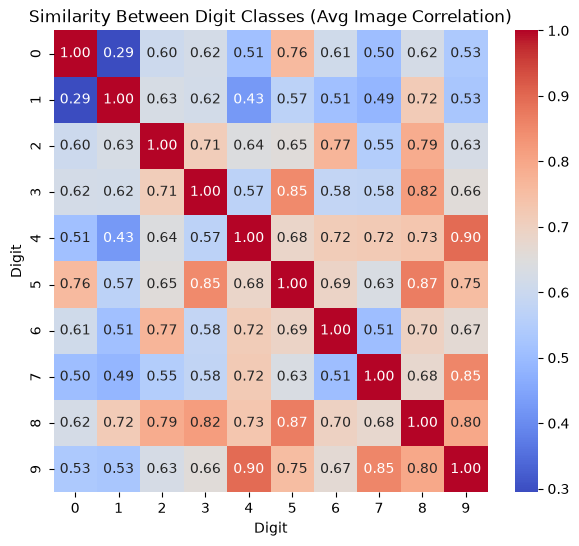

In [8]:
avg_images_flat = np.array([X_train[y_train == d].mean(axis=0).flatten() for d in range(10)])
corr_matrix = np.corrcoef(avg_images_flat)

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Similarity Between Digit Classes (Avg Image Correlation)")
plt.xlabel("Digit")
plt.ylabel("Digit")
plt.show()

## 9. Preprocessing for CNN

- `.reshape(-1, 28, 28, 1)` — Conv2D layers expect 4D input `(batch, height, width, channels)`. MNIST is grayscale so channels=1. `-1` lets numpy infer the batch size.
- `.astype("float32")` — converts pixels from `uint8` (0-255 ints) to float, required for neural network math.
- `/ 255.0` — normalizes pixels to [0, 1], which trains faster and more stably than raw 0-255 values.

In [9]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print("CNN input shape:", X_train_cnn.shape)

CNN input shape: (60000, 28, 28, 1)


## 10. Build the CNN — Line by Line

- `Sequential` — stacks layers linearly, each layer feeding the next. Fine for this architecture (no branching needed).
- `Conv2D(32, kernel_size=3, activation="relu", input_shape=(28,28,1))` — first conv layer, learns **32 filters** (3×3 each) that act as feature detectors (edges, simple textures). `input_shape` is only needed on the first layer. Output shape: `(26, 26, 32)`.
- `MaxPooling2D(pool_size=2)` — takes the max value in every 2×2 block, halving spatial size. Reduces computation and adds mild translation invariance. Output: `(13, 13, 32)`.
- `Conv2D(64, kernel_size=3, activation="relu")` — second conv layer, **64 filters** now — deeper layers detect more complex patterns built from the simple ones found earlier. Output: `(11, 11, 64)`.
- `MaxPooling2D(pool_size=2)` — downsamples again. Output: `(5, 5, 64)`.
- `Conv2D(64, kernel_size=3, activation="relu")` — a third conv pass for higher-level features before flattening. Output: `(3, 3, 64)`.
- `Flatten()` — converts the 3D feature map `(3,3,64)` into a 1D vector of length 576, bridging the convolutional part to the dense (classification) part.
- `Dense(64, activation="relu")` — fully-connected layer combining extracted features into higher-level representations.
- `Dense(10, activation="softmax")` — output layer, one neuron per digit class; softmax converts outputs into probabilities summing to 1.

In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, kernel_size=3, activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=2),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    layers.Conv2D(64, kernel_size=3, activation="relu"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

C:\Users\Mohana\tensorflow_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Compile the Model

- `optimizer="adam"` — updates model weights during training; Adam adapts the learning rate automatically, a strong general default.
- `loss="sparse_categorical_crossentropy"` — measures prediction error; "sparse" because labels are plain integers (0-9), not one-hot vectors.
- `metrics=["accuracy"]` — tracked for human-readable monitoring, not used in the weight updates themselves.

In [11]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

## 12. Train the Model

- `epochs=5` — the full training set passes through the network 5 times.
- `batch_size=64` — weights update after every 64 samples, balancing speed and stability.
- `validation_split=0.1` — holds out 10% of training data (untouched by weight updates) to monitor overfitting during training.

In [12]:
history = model.fit(X_train_cnn, y_train, epochs=5, batch_size=64,
                     validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9395 - loss: 0.1999 - val_accuracy: 0.9852 - val_loss: 0.0568
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9821 - loss: 0.0561 - val_accuracy: 0.9868 - val_loss: 0.0444
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9857 - val_loss: 0.0458
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9898 - loss: 0.0316 - val_accuracy: 0.9883 - val_loss: 0.0441
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.9908 - val_loss: 0.0353


## 13. Evaluate on Test Set
The test set was never seen during training, so this gives an honest performance estimate.

In [13]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9915 - loss: 0.0261
Test accuracy: 0.992


## 14. Plot Training History
If validation loss starts rising while training loss keeps falling, that's a visual sign of overfitting.

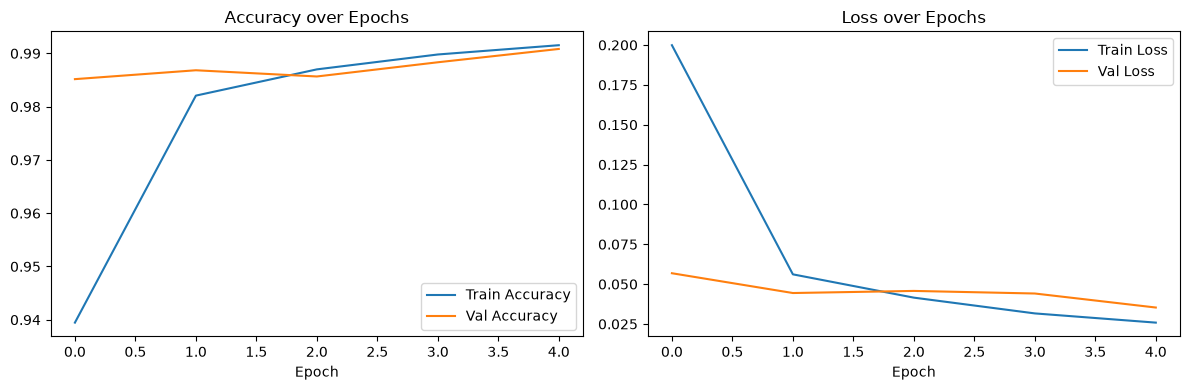

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()